# 02 — Numerical experiments

This notebook contains the **data-independent numerical experiments** used to study the relationships among the Torri, Davis–Lo, and Vasicek default-count model families.

It is intentionally separate from `03_data_analysis.ipynb`, which reads either the proprietary Moody's annual data (when locally available) or the synthetic replacement generated by `01_generate_synthetic_data.ipynb`.

## Scope

This notebook reproduces the controlled model-comparison calculations used in the paper:

1. matched-*(m, rho)* one-period model comparison;
2. Torri activation-probability and tail-risk trade-off;
3. static one-period KL projections (Table VI);
4. KL projection under environmental fluctuations (Fig. 8).

No Moody's data are read by this notebook.

Generated figures are written to `figure/` and numerical tables to `pdata/`.


In [1]:
# --- ADDED FOR REFACTOR ---
from modules.models import (
    default_corr_from_asset_corr,
    es_from_pmf,
    find_params_on_iso_Torri,
    invert_asset_corr_from_default_corr,
    m_rho_from_pmf,
    moments_from_pmf,
    pmf_Torri,
    pmf_Vas,
    tail_metrics_from_pmf,
    var_from_pmf
)
# --------------------------

from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from math import lgamma
from scipy.optimize import minimize, brentq, least_squares
from scipy.special import gammaln, expit
from scipy.stats import norm, multivariate_normal
from numpy.polynomial.hermite import hermgauss

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

FIGURE_DIR = Path("figure")
PDATA_DIR = Path("pdata")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PDATA_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

print(f"figure output: {FIGURE_DIR.resolve()}")
print(f"numeric output: {PDATA_DIR.resolve()}")


figure output: [LOCAL_REPO_PATH]/figure
numeric output: [LOCAL_REPO_PATH]/pdata


## 1. Common numerical utilities

These functions support PMF normalization, moments, survival functions, and tail-risk calculations.

Some of these utilities are also needed by `03_data_analysis.ipynb`; after both notebooks are finalized, the shared functions can be moved to `modules/` without changing the notebook-level workflow.


In [2]:
# =========================
# Numeric utilities
# =========================

def log_comb(n: int, k: int) -> float:
    """log( n choose k )"""
    return lgamma(n+1) - lgamma(k+1) - lgamma(n-k+1)

def logsumexp_arr(logw: np.ndarray) -> float:
    """stable log(sum(exp(logw))) for 1D array"""
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.sum(np.exp(logw - m)))

def logsumexp2(x: float, y: float) -> float:
    """log(exp(x)+exp(y))"""
    m = max(x, y)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.exp(x-m) + np.exp(y-m))

def logsubexp(a: float, b: float) -> float:
    """log(exp(a)-exp(b)) with a>b; otherwise -inf"""
    if b >= a:
        return -np.inf
    return a + np.log1p(-np.exp(b - a))

def normalize_logpmf(logpmf: np.ndarray) -> np.ndarray:
    """Normalize log-PMF array to PMF (handles -inf safely)."""
    logpmf = np.where(np.isfinite(logpmf), logpmf, -np.inf)
    m = np.max(logpmf)
    if not np.isfinite(m):
        return np.full_like(logpmf, np.nan, dtype=float)
    z = np.sum(np.exp(logpmf - m))
    return np.exp(logpmf - (m + np.log(z)))

# =========================
# Tail & moments utilities
# =========================





def survival_from_pmf(pmf: np.ndarray) -> np.ndarray:
    """S[h] = P(L >= h)"""
    return np.flip(np.cumsum(np.flip(pmf)))



## 2. Torri threshold-type contagion model

The Torri model has parameters `p`, `u`, and `v`. Along an iso-*(m, rho)* manifold it retains one residual degree of freedom, which changes the activation probability and tail shape.


In [3]:

def moments_from_params_Torri(n: int, p: float, u: float, v: float):
    """Closed-form (m, rho) for Torri parameterization used in this notebook."""
    b = (1-p)*(1-u)
    s = 1 - p*v

    # mean (fraction)
    m = p + b*(1 - s**(n-1))

    # pair moment term
    a_alt = s + p - 1
    s_pow = np.exp((n-2)*np.log(s)) if n > 2 else 1.0
    E = (p+b)**2 - b*(2*a_alt + b)*s_pow

    cov = E - m**2
    den = m*(1-m)
    rho = np.nan if den <= 1e-15 else cov/den
    return float(m), float(rho)



## 3. Davis–Lo cumulative-contagion model

The Davis–Lo model has parameters `p` and `q`. Conditional on the number of idiosyncratic seed defaults, additional default probability increases cumulatively with the number of seeds.


In [4]:
def pmf_LD(n: int, p: float, q: float) -> np.ndarray:
    """
    Davis–Lo Infectious Default Model PMF via mixture:
      K ~ Bin(n,p), L|K=k = k + Bin(n-k, r_k), r_k = 1 - (1-q)^k
    Stable implementation using expm1/log1p and log-sum-exp.
    """
    if not (0.0 <= p <= 1.0 and 0.0 <= q <= 1.0):
        raise ValueError("p and q must be in [0,1].")

    # log P(K=k)
    logP_K = np.full(n+1, -np.inf, dtype=float)
    if p == 0.0:
        logP_K[0] = 0.0
    elif p == 1.0:
        logP_K[n] = 0.0
    else:
        log_p = np.log(p)
        log_1mp = np.log1p(-p)
        for k in range(n+1):
            logP_K[k] = log_comb(n, k) + k*log_p + (n-k)*log_1mp

    # r_k = 1 - (1-q)^k  (stable)
    r = np.zeros(n+1, dtype=float)
    if q == 0.0:
        r[:] = 0.0
    elif q == 1.0:
        r[0] = 0.0
        r[1:] = 1.0
    else:
        l = np.log1p(-q)
        ks = np.arange(n+1, dtype=float)
        r = -np.expm1(ks * l)

    pmf_log = np.full(n+1, -np.inf, dtype=float)

    for h in range(n+1):
        # sum over k=0..h
        terms = np.full(h+1, -np.inf, dtype=float)
        for k in range(h+1):
            if not np.isfinite(logP_K[k]):
                continue
            t = h - k
            nk = n - k
            rk = r[k]
            if t < 0 or t > nk:
                continue

            if rk == 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk == 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_rk = np.log(rk)
                log_1mrk = np.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_rk + (nk-t)*log_1mrk

            terms[k] = logP_K[k] + log_bin

        pmf_log[h] = logsumexp_arr(terms)

    return normalize_logpmf(pmf_log)

def m_rho_LD(n: int, p: float, q: float):
    """
    Closed-form (m, rhoZ) for Davis–Lo.
    m = 1 - (1-p)*(1-qp)^(n-1)
    Cov = (1-p)^2 * [ (1 - 2pq + p q^2)^(n-2) - (1-pq)^(2(n-1)) ]
    rho = Cov / (m(1-m))
    """
    m = 1.0 - (1.0 - p) * (1.0 - q*p)**(n-1)
    if n < 2:
        return float(m), np.nan
    termA = (1.0 - 2.0*p*q + p*(q**2))**(n-2)
    termB = (1.0 - p*q)**(2*(n-1))
    cov = (1.0 - p)**2 * (termA - termB)
    var = m*(1.0-m)
    rho = cov/var if var > 1e-15 else np.nan
    return float(m), float(rho)

def solve_pq_for_mrho_LD(n: int, m_target: float, rho_target: float,
                         p_bounds=(1e-10, 1-1e-10), q_bounds=(1e-10, 1-1e-10),
                         n_tries: int = 60, w_rho: float = 1.0):
    """Fit (p,q) to match (m_target, rho_target) by multi-start L-BFGS-B."""
    p_lo, p_hi = p_bounds
    q_lo, q_hi = q_bounds

    def objective(x):
        p, q = x
        if not (p_lo <= p <= p_hi and q_lo <= q <= q_hi):
            return 1e9
        m, rho = m_rho_LD(n, p, q)
        if not np.isfinite(m) or not np.isfinite(rho):
            return 1e9
        return (m - m_target)**2 + w_rho*(rho - rho_target)**2

    best = None
    rng = np.random.default_rng(SEED)

    init_list = [
        (min(max(m_target, p_lo), p_hi), 0.05),
        (0.01, 0.10), (0.05, 0.05), (0.10, 0.10), (0.30, 0.05), (0.50, 0.05),
    ]
    for _ in range(max(0, n_tries - len(init_list))):
        init_list.append((rng.uniform(p_lo, p_hi), rng.uniform(q_lo, q_hi)))

    for (p0, q0) in init_list:
        res = minimize(
            objective,
            x0=np.array([p0, q0], dtype=float),
            method="L-BFGS-B",
            bounds=[(p_lo, p_hi), (q_lo, q_hi)],
        )
        if not res.success:
            continue

        p_hat, q_hat = res.x
        m_hat, rho_hat = m_rho_LD(n, p_hat, q_hat)
        err_m = m_hat - m_target
        err_r = rho_hat - rho_target
        score = err_m**2 + w_rho*(err_r**2)

        cand = dict(
            p=float(p_hat), q=float(q_hat),
            m=float(m_hat), rho=float(rho_hat),
            err_m=float(err_m), err_rho=float(err_r),
            score=float(score), fun=float(res.fun),
            success=bool(res.success), message=str(res.message)
        )
        if (best is None) or (cand["score"] < best["score"]):
            best = cand

    if best is None:
        raise RuntimeError("Optimization did not converge; check whether the requested (m, rho) is attainable in the Davis–Lo family.")
    return best


## 4. Vasicek common-factor model

The Vasicek model is evaluated by Gauss–Hermite quadrature. The observable pairwise default correlation is obtained from the latent asset correlation.


In [5]:
def phi2_aa(a: float, rhoA: float) -> float:
    cov = np.array([[1.0, rhoA],
                    [rhoA, 1.0]])
    return float(multivariate_normal.cdf([a, a], mean=[0.0, 0.0], cov=cov))





## 5. Matched-*(m, rho)* calibration

The representative comparison used throughout the controlled experiments is

- portfolio size: `n = 200`
- mean default probability: `m = 0.02`
- pairwise default correlation: `rho = 0.08`

The Torri family yields a sequence of solutions along the iso-*(m, rho)* manifold, whereas Davis–Lo and Vasicek are single calibrated points.


In [6]:
# -------------------------
# Config
# -------------------------
n = 200
m_target = 0.02
rho_target = 0.08
alpha = 0.99
strict_es = False  # ES = E[L | L >= VaR] by default

# -------------------------
# Torri: scan p and solve
# -------------------------
p_grid = np.linspace(0.001, m_target*0.999, 10)
sols_Torri = find_params_on_iso_Torri(n, m_target, rho_target, p_grid)

# -------------------------
# Davis–Lo: fit (p,q)
# -------------------------
sol_LD = solve_pq_for_mrho_LD(n=n, m_target=m_target, rho_target=rho_target, n_tries=60, w_rho=1.0)
pmf_ld = pmf_LD(n, sol_LD["p"], sol_LD["q"])

# -------------------------
# Vasicek: implied asset corr
# -------------------------
rhoA_hat = invert_asset_corr_from_default_corr(m_target, rho_target)
pmf_vas = pmf_Vas(n, m_target, rhoA_hat, n_gh=60)

# -------------------------
# Summary table: VaR/ES and (m,rho) checks
# -------------------------
rows = []

for d in sols_Torri:
    pmf = pmf_Torri(n, d["p"], d["u"], d["v"])
    tm = tail_metrics_from_pmf(pmf, alpha=alpha, strict_es=strict_es)
    m_par, rho_par = moments_from_params_Torri(n, d["p"], d["u"], d["v"])
    m_pmf, rho_pmf, _ = m_rho_from_pmf(pmf)
    rows.append({
        "Model": "Torri",
        "p": d["p"], "u": d["u"], "v": d["v"],
        "q": np.nan, "rhoA": np.nan,
        "m_param": m_par, "rho_param": rho_par,
        "m_pmf": m_pmf, "rho_pmf": rho_pmf,
        "VaR99": tm["VaR"], "ES99": tm["ES"],
        "ES-VaR": tm["ES_minus_VaR"], "ES/VaR": tm["ES_over_VaR"],
    })

tm_ld = tail_metrics_from_pmf(pmf_ld, alpha=alpha, strict_es=strict_es)
m_ld, rho_ld, _ = m_rho_from_pmf(pmf_ld)
rows.append({
    "Model": "Davis–Lo",
    "p": sol_LD["p"], "u": np.nan, "v": np.nan,
    "q": sol_LD["q"], "rhoA": np.nan,
    "m_param": sol_LD["m"], "rho_param": sol_LD["rho"],
    "m_pmf": m_ld, "rho_pmf": rho_ld,
    "VaR99": tm_ld["VaR"], "ES99": tm_ld["ES"],
    "ES-VaR": tm_ld["ES_minus_VaR"], "ES/VaR": tm_ld["ES_over_VaR"],
})

tm_v = tail_metrics_from_pmf(pmf_vas, alpha=alpha, strict_es=strict_es)
m_v, rho_v, _ = m_rho_from_pmf(pmf_vas)
rows.append({
    "Model": "Vasicek",
    "p": m_target, "u": np.nan, "v": np.nan,
    "q": np.nan, "rhoA": rhoA_hat,
    "m_param": m_target, "rho_param": default_corr_from_asset_corr(m_target, rhoA_hat),
    "m_pmf": m_v, "rho_pmf": rho_v,
    "VaR99": tm_v["VaR"], "ES99": tm_v["ES"],
    "ES-VaR": tm_v["ES_minus_VaR"], "ES/VaR": tm_v["ES_over_VaR"],
})

df_summary = pd.DataFrame(rows)
df_summary = df_summary.sort_values(["Model","p"], na_position="last")

display(df_summary)


,Model,p,u,v,q,rhoA,m_param,rho_param,m_pmf,rho_pmf,VaR99,ES99,ES-VaR,ES/VaR
7,Davis–Lo,0.001246,NaN,NaN,0.076475,NaN,0.02,0.08,0.02,0.08,33,37.915131,4.915131,1.148943
0,Torri,0.003109,0.898636,0.295516,NaN,NaN,0.02,0.08,0.02,0.08,29,30.591544,1.591544,1.054881
1,Torri,0.005218,0.887343,0.136180,NaN,NaN,0.02,0.08,0.02,0.08,31,32.817221,1.817221,1.058620
2,Torri,0.007327,0.871519,0.071763,NaN,NaN,0.02,0.08,0.02,0.08,34,36.073926,2.073926,1.060998
3,Torri,0.009436,0.848454,0.038857,NaN,NaN,0.02,0.08,0.02,0.08,38,40.468458,2.468458,1.064959
4,Torri,0.011544,0.812739,0.020350,NaN,NaN,0.02,0.08,0.02,0.08,44,47.075229,3.075229,1.069892
5,Torri,0.013653,0.751775,0.009666,NaN,NaN,0.02,0.08,0.02,0.08,54,58.132238,4.132238,1.076523
6,Torri,0.015762,0.627897,0.003710,NaN,NaN,0.02,0.08,0.02,0.08,70,78.737869,8.737869,1.124827
8,Vasicek,0.020000,NaN,NaN,NaN,0.343882,0.02,0.08,0.02,0.08,40,55.817409,15.817409,1.395435


## 6. Distributional comparison under matched first and second moments

The next cells compare PMFs and survival functions for three representative Torri solutions (high, intermediate, and low activation probability), together with the matched Davis–Lo and Vasicek distributions.

These are controlled model-family comparisons; no empirical data enter.


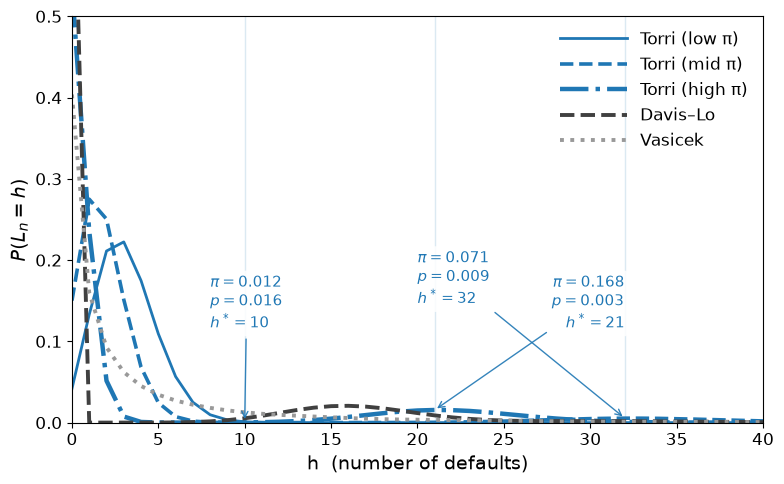

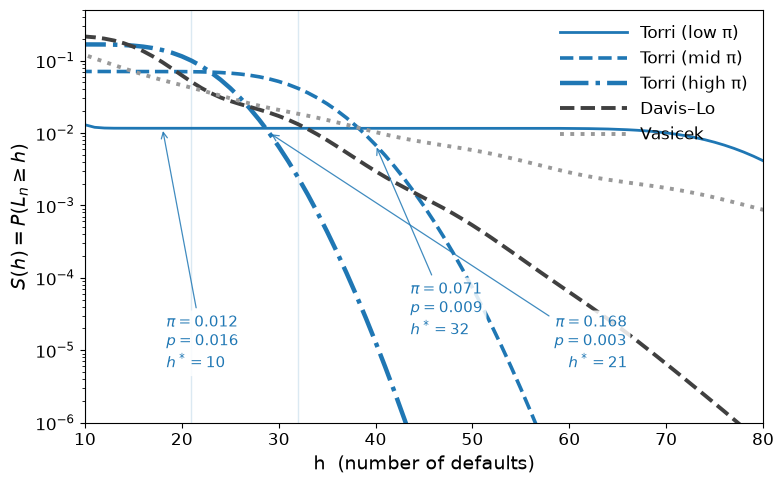

In [7]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# =========================
# Paper-ready style
# =========================
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# =========================
# Helpers
# =========================
def systemic_prob_torri(n, p, v):
    # π = P(I_C^{(n)} = 1) = 1 - (1 - p v)^n
    return 1.0 - (1.0 - p * v) ** n

def high_h_peak(pmf, h0=10):
    """
    Find the peak location in the 'high-h' region (h>=h0).
    Returns (h_peak, y_peak).
    """
    h0 = int(h0)
    h0 = min(max(h0, 0), len(pmf)-1)
    h_peak = h0 + int(np.argmax(pmf[h0:]))
    return h_peak, float(pmf[h_peak])

def survival_from_pmf_safe(pmf, eps=1e-300):
    S = survival_from_pmf(pmf)
    return np.maximum(S, eps)

def select_three_by_pi(sols_Torri, n):
    """
    Select 3 representative Torri solutions by π:
    low (min), mid (median), high (max).
    Returns [(pi_low,d_low), (pi_mid,d_mid), (pi_high,d_high)] sorted by pi.
    """
    torri = [(systemic_prob_torri(n, d["p"], d["v"]), d) for d in sols_Torri]
    torri.sort(key=lambda t: t[0])
    if len(torri) == 0:
        raise ValueError("sols_Torri is empty.")

    idxs = [0, len(torri)//2, len(torri)-1]
    rep = [torri[i] for i in idxs]
    rep.sort(key=lambda t: t[0])  # ensure low < mid < high
    return rep

# =========================
# Choose representative Torri curves
# =========================
rep_T = select_three_by_pi(sols_Torri, n)  # [(pi,d_low),(pi,d_mid),(pi,d_high)]

# --- OPTIONAL ---
# If you want p shown in annotation text, set True.
INCLUDE_P_IN_ANNOT = True

labels_T = [
    "Torri (low π)",
    "Torri (mid π)",
    "Torri (high π)"
]


# same color family, but distinguish by line/marker
torri_styles = [
    dict(color="tab:blue", linestyle="-",  linewidth=2.0, marker="", markevery=5, ms=8,
         markeredgecolor="white", markeredgewidth=0.8),
    dict(color="tab:blue", linestyle="--", linewidth=2.6, marker="", markevery=5, ms=8,
         markeredgecolor="white", markeredgewidth=0.8),
    dict(color="tab:blue", linestyle="-.",  linewidth=3.2, marker="", markevery=5, ms=8,
         markeredgecolor="white", markeredgewidth=0.8),
]


# ---- Annotation slots (axes fraction): adjust ONCE and you are done ----
ann_pos_pmf  = [(0.20, 0.22), (0.50, 0.28), (0.80, 0.22)]
ann_pos_surv = [(0.12, 0.12), (0.48, 0.20), (0.80, 0.12)]

# Arrow shortening for survival to avoid crossing
SURV_ARROW_SHIFT = 8  # move arrow target to the right by this many h steps

# Axis ranges (edit if you like)
PMF_XMAX = 40
PMF_YMAX = 0.5

SURV_XMIN = 10
SURV_XMAX = min(n, 80)
SURV_YMIN = 1e-6
SURV_YMAX = 0.5

# Shared x-grid
x = np.arange(n + 1)

def torri_annot_text(pi, d, h_peak):
    if INCLUDE_P_IN_ANNOT:
        return rf"$\pi={pi:.3f}$" + "\n" + rf"$p={d['p']:.3f}$" + "\n" + rf"$h^*={h_peak}$"
    else:
        return rf"$\pi={pi:.3f}$" + "\n" + rf"$h^*={h_peak}$"

# =========================
# 1) PMF plot
# =========================
plt.figure(figsize=(8.0, 5.0))

for (pi, d), lab, sty, (tx, ty) in zip(rep_T, labels_T, torri_styles, ann_pos_pmf):
    pmf = pmf_Torri(n, d["p"], d["u"], d["v"])

    plt.plot(
        x, pmf,
        label=lab,
        **sty
    )

    # mark high-h peak in PMF
    h_peak, y_peak = high_h_peak(pmf, h0=10)
    plt.axvline(h_peak, color=sty["color"], alpha=0.16, linewidth=1.0)

    ha = "right" if tx > 0.65 else "left"
    plt.annotate(
        torri_annot_text(pi, d, h_peak),
        xy=(h_peak, y_peak), xycoords="data",
        xytext=(tx, ty), textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=1.0, color=sty["color"], alpha=0.9),
        fontsize=11,
        fontweight="bold",
        color=sty["color"],
        ha=ha, va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
    )

# Davis–Lo & Vasicek
plt.plot(x, pmf_ld, linestyle="--", linewidth=2.8, color="0.25", label="Davis–Lo")
plt.plot(x, pmf_vas, linestyle=":",  linewidth=2.8, color="0.60", label="Vasicek")

plt.xlim(0, PMF_XMAX)
plt.ylim(0, PMF_YMAX)
plt.xlabel("h  (number of defaults)")
plt.ylabel(r"$P(L_n = h)$")
plt.legend(
    frameon=False,
    loc="upper right",
    handlelength=4
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "static_matched_pmf.pdf", bbox_inches="tight")
plt.show()


# =========================
# 2) Survival (right tail) plot
# =========================
plt.figure(figsize=(8.0, 5.0))
eps = 1e-300

for (pi, d), lab, sty, (tx, ty) in zip(rep_T, labels_T, torri_styles, ann_pos_surv):
    pmf = pmf_Torri(n, d["p"], d["u"], d["v"])
    S = np.maximum(survival_from_pmf(pmf), eps)

    plt.plot(
        x, S,
        label=lab,
        **sty
    )

    # systemic-mode marker: use PMF high-h peak
    h_peak, _ = high_h_peak(pmf, h0=10)
    plt.axvline(h_peak, color=sty["color"], alpha=0.16, linewidth=1.0)

    # arrow target slightly to the right to reduce crossings
    h_arrow = min(h_peak + SURV_ARROW_SHIFT, SURV_XMAX)
    y_arrow = float(S[h_arrow])

    ha = "right" if tx > 0.65 else "left"

    plt.annotate(
        torri_annot_text(pi, d, h_peak),
        xy=(h_arrow, y_arrow), xycoords="data",
        xytext=(tx, ty), textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.9, color=sty["color"], alpha=0.85),
        fontsize=11,
        fontweight="bold",
        color=sty["color"],
        ha=ha, va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
        zorder=10
    )

# ---- Davis–Lo & Vasicek ----
S_LD = np.maximum(survival_from_pmf(pmf_ld), eps)
S_VA = np.maximum(survival_from_pmf(pmf_vas), eps)

plt.plot(x, S_LD, linestyle="--", linewidth=2.8, color="0.25", label="Davis–Lo")
plt.plot(x, S_VA, linestyle=":",  linewidth=2.8, color="0.60", label="Vasicek")

plt.yscale("log")
plt.xlim(SURV_XMIN, SURV_XMAX)
plt.ylim(SURV_YMIN, SURV_YMAX)

plt.xlabel("h  (number of defaults)")
plt.ylabel(r"$S(h)=P(L_n \geq h)$")
plt.legend(
    frameon=False,
    loc="upper right",
    handlelength=4
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "static_matched_survival.pdf", bbox_inches="tight")
plt.show()


## 7. Torri activation probability and tail-risk trade-off

This section reproduces the controlled calculation underlying Fig. 4 of the current manuscript. Along the same iso-*(m, rho)* manifold, the Torri activation probability changes even though the first two dependence summaries remain fixed.


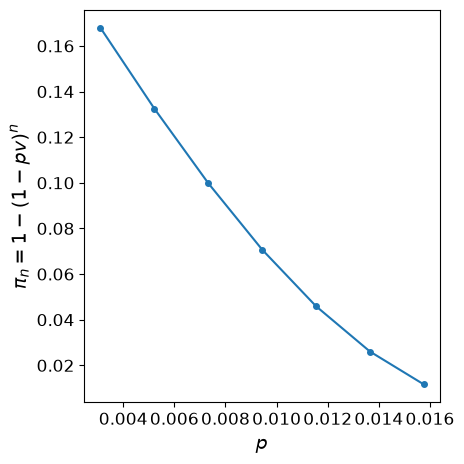

In [8]:
# -------------------------
# π(p) plot for Torri on iso-(m, rho)
#   π = P(I_C^{(n)}=1) = 1 - (1 - p v)^n
# -------------------------
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})


def pi_torri(n, p, v):
    return 1.0 - (1.0 - p * v) ** n

# sols_Torri: list of dicts like {"p":..., "u":..., "v":...}
ps = np.array([d["p"] for d in sols_Torri], dtype=float)
vs = np.array([d["v"] for d in sols_Torri], dtype=float)
pis = pi_torri(n, ps, vs)

# sort by p for a clean curve
order = np.argsort(ps)
ps_s = ps[order]
pis_s = pis[order]


plt.figure(figsize=(4.8, 4.8))
plt.plot(ps_s, pis_s, marker="o", markersize=4)

plt.xlabel(r"$p$")
plt.ylabel(r"$\pi_n = 1 - (1 - p v)^n$")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig4a_activation_probability.pdf", bbox_inches="tight")
plt.show()


In [9]:
# =========================
# Settings
# =========================
alpha = 0.99
strict_es = False  # True -> E[L | L > VaR], False -> E[L | L >= VaR]

# =========================
# Paper style
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})

# =========================
# Build one table (compute ONCE)
# =========================
rows = []

# --- Torri ---
for d in sols_Torri:
    p_t = float(d["p"])
    u_t = float(d["u"])
    v_t = float(d["v"])
    pi_n = 1.0 - (1.0 - p_t * v_t) ** n

    pmf = pmf_Torri(n, p_t, u_t, v_t)
    met = tail_metrics_from_pmf(pmf, alpha=alpha, strict_es=strict_es)

    rows.append({
        "Model": "Torri",
        "p": p_t,
        "u": u_t,
        "v": v_t,
        "pi_n": pi_n,
        "VaR_99": float(met["VaR"]),
        "ES_99": float(met["ES"]),
        "ES_minus_VaR": float(met["ES_minus_VaR"]),
        "ES_div_VaR": float(met["ES_over_VaR"]),
    })

# --- LD ---
met_ld = tail_metrics_from_pmf(pmf_ld, alpha=alpha, strict_es=strict_es)
rows.append({
    "Model": "LD",
    "p": float(sol_LD["p"]) if ("sol_LD" in globals() and sol_LD is not None and "p" in sol_LD) else np.nan,
    "u": np.nan,
    "v": np.nan,
    "pi_n": np.nan,
    "VaR_99": float(met_ld["VaR"]),
    "ES_99": float(met_ld["ES"]),
    "ES_minus_VaR": float(met_ld["ES_minus_VaR"]),
    "ES_div_VaR": float(met_ld["ES_over_VaR"]),
})

# --- Vasicek ---
met_vas = tail_metrics_from_pmf(pmf_vas, alpha=alpha, strict_es=strict_es)
rows.append({
    "Model": "Vasicek",
    "p": float(m_target) if ("m_target" in globals()) else np.nan,
    "u": np.nan,
    "v": np.nan,
    "pi_n": np.nan,
    "VaR_99": float(met_vas["VaR"]),
    "ES_99": float(met_vas["ES"]),
    "ES_minus_VaR": float(met_vas["ES_minus_VaR"]),
    "ES_div_VaR": float(met_vas["ES_over_VaR"]),
})

df = pd.DataFrame(rows)[
    ["Model", "p", "u", "v", "pi_n", "VaR_99", "ES_99", "ES_minus_VaR", "ES_div_VaR"]
]

# order: Torri(sorted by pi_n), LD, Vasicek
df = pd.concat([
    df[df["Model"] == "Torri"].sort_values("pi_n"),
    df[df["Model"] == "LD"],
    df[df["Model"] == "Vasicek"],
], ignore_index=True)

print(df)
df.to_csv(PDATA_DIR / "fig4_tail_metrics_vs_pi.csv", index=False)
print(f"\nSaved: {PDATA_DIR / 'fig4_tail_metrics_vs_pi.csv'}")


     Model         p         u         v      pi_n  VaR_99      ES_99  \
0    Torri  0.015762  0.627897  0.003710  0.011629    70.0  78.737869   
1    Torri  0.013653  0.751775  0.009666  0.026051    54.0  58.132238   
2    Torri  0.011544  0.812739  0.020350  0.045905    44.0  47.075229   
3    Torri  0.009436  0.848454  0.038857  0.070716    38.0  40.468458   
4    Torri  0.007327  0.871519  0.071763  0.099841    34.0  36.073926   
5    Torri  0.005218  0.887343  0.136180  0.132519    31.0  32.817221   
6    Torri  0.003109  0.898636  0.295516  0.167923    29.0  30.591544   
7       LD  0.001246       NaN       NaN       NaN    33.0  37.915131   
8  Vasicek  0.020000       NaN       NaN       NaN    40.0  55.817409   

   ES_minus_VaR  ES_div_VaR  
0      8.737869    1.124827  
1      4.132238    1.076523  
2      3.075229    1.069892  
3      2.468458    1.064959  
4      2.073926    1.060998  
5      1.817221    1.058620  
6      1.591544    1.054881  
7      4.915131    1.148943  

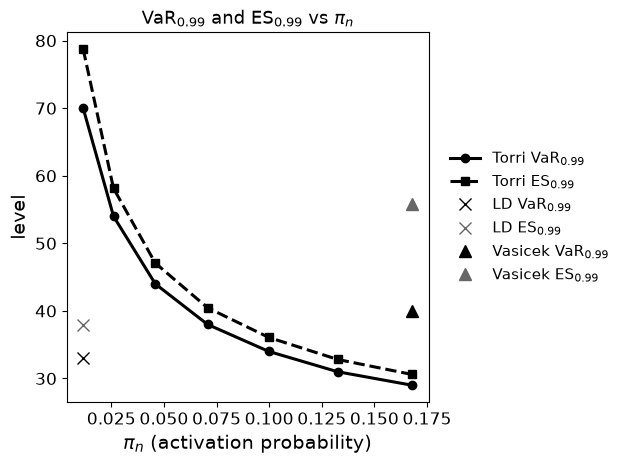

In [10]:
# =========================
# Plot from df (no recomputation)
# =========================
dfT = df[df["Model"]=="Torri"].copy()
ps   = dfT["p"].to_numpy(float)
varT = dfT["VaR_99"].to_numpy(float)
esT  = dfT["ES_99"].to_numpy(float)
tmeT = dfT["ES_minus_VaR"].to_numpy(float)

var_ld, es_ld, tme_ld = df.loc[df["Model"]=="LD", ["VaR_99","ES_99","ES_minus_VaR"]].iloc[0].astype(float)
var_vas, es_vas, tme_vas = df.loc[df["Model"]=="Vasicek", ["VaR_99","ES_99","ES_minus_VaR"]].iloc[0].astype(float)

# =========================
# Compute π_n for Torri
# =========================
pis = 1.0 - (1.0 - dfT["p"].to_numpy(float) * dfT["v"].to_numpy(float))**n

# =========================
# Sort by π (見やすさのため)
# =========================
order = np.argsort(pis)
pis  = pis[order]
varT = varT[order]
esT  = esT[order]
tmeT = tmeT[order]

# =========================
# Figure 1: VaR & ES vs π
# =========================
fig2, ax = plt.subplots(figsize=(7.6, 4.8))

# Torri
ax.plot(pis, varT, marker="o", linestyle="-",  color="black",
        label=r"Torri $\mathrm{VaR}_{0.99}$")

ax.plot(pis, esT,  marker="s", linestyle="--", color="black",
        label=r"Torri $\mathrm{ES}_{0.99}$")

# LD（単一点）
ax.plot(pis[0], var_ld, marker="x", color="black", linestyle="None", markersize=9,
        label=r"LD $\mathrm{VaR}_{0.99}$")
ax.plot(pis[0], es_ld,  marker="x", color="0.4", linestyle="None", markersize=9,
        label=r"LD $\mathrm{ES}_{0.99}$")

# Vasicek（単一点）
ax.plot(pis[-1], var_vas, marker="^", color="black", linestyle="None", markersize=8,
        label=r"Vasicek $\mathrm{VaR}_{0.99}$")
ax.plot(pis[-1], es_vas,  marker="^", color="0.4", linestyle="None", markersize=8,
        label=r"Vasicek $\mathrm{ES}_{0.99}$")

ax.set_xlabel(r"$\pi_n$ (activation probability)")
ax.set_ylabel("level")
ax.set_title(r"$\mathrm{VaR}_{0.99}$ and $\mathrm{ES}_{0.99}$ vs $\pi_n$")

ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig2.tight_layout(rect=[0, 0, 0.85, 1])
fig2.savefig(
    FIGURE_DIR / "fig4b_tailrisk_vs_activation.pdf",
    bbox_inches="tight"
)
plt.show()


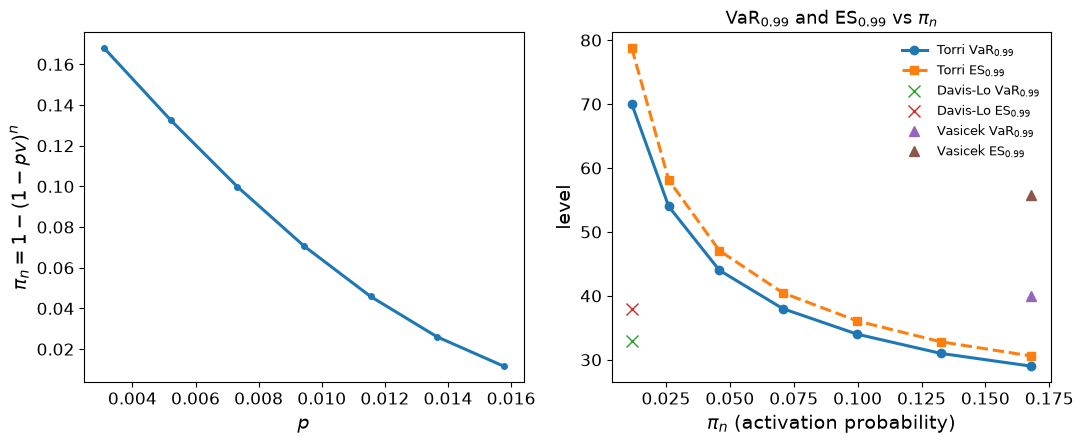

In [11]:
# Combined two-panel version corresponding to manuscript Fig. 4.

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))

# Left: activation probability along the iso-(m, rho) manifold
axes[0].plot(ps_s, pis_s, marker="o", markersize=4)
axes[0].set_xlabel(r"$p$")
axes[0].set_ylabel(r"$\pi_n = 1-(1-pv)^n$")

# Right: VaR and ES versus activation probability
axes[1].plot(pis, varT, marker="o", linestyle="-", label=r"Torri $\mathrm{VaR}_{0.99}$")
axes[1].plot(pis, esT, marker="s", linestyle="--", label=r"Torri $\mathrm{ES}_{0.99}$")
axes[1].plot(pis[0], var_ld, marker="x", linestyle="None", markersize=8,
             label=r"Davis-Lo $\mathrm{VaR}_{0.99}$")
axes[1].plot(pis[0], es_ld, marker="x", linestyle="None", markersize=8,
             label=r"Davis-Lo $\mathrm{ES}_{0.99}$")
axes[1].plot(pis[-1], var_vas, marker="^", linestyle="None", markersize=7,
             label=r"Vasicek $\mathrm{VaR}_{0.99}$")
axes[1].plot(pis[-1], es_vas, marker="^", linestyle="None", markersize=7,
             label=r"Vasicek $\mathrm{ES}_{0.99}$")
axes[1].set_xlabel(r"$\pi_n$ (activation probability)")
axes[1].set_ylabel("level")
axes[1].set_title(r"$\mathrm{VaR}_{0.99}$ and $\mathrm{ES}_{0.99}$ vs $\pi_n$")
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig4_frequency_severity_tradeoff.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "fig4_frequency_severity_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Static one-period KL projections — Table VI

For each representative target distribution, minimize the directed KL divergence over each competing model family.

The paper reports four target distributions:

- Torri with high activation probability;
- Torri with intermediate activation probability;
- Torri with low activation probability;
- Davis–Lo.

The resulting table is a structural comparison among static one-period model families. It is not an empirical model-selection criterion.


In [12]:
# ============================================================
# Static one-period KL projections (manuscript Table VI)
# ============================================================

from scipy.special import expit, logit as scipy_logit
from scipy.stats import binom

KL_EPS = 1e-14
KL_GH_N = 60

def normalize_pmf_kl(pmf, eps=KL_EPS):
    pmf = np.asarray(pmf, dtype=float)
    pmf = np.maximum(pmf, eps)
    return pmf / pmf.sum()

def kl_divergence_pmf(P, Q, eps=KL_EPS):
    P = normalize_pmf_kl(P, eps)
    Q = normalize_pmf_kl(Q, eps)
    return float(np.sum(P * (np.log(P) - np.log(Q))))

def pmf_LD_fast(n, p, q):
    """
    Numerically equivalent Davis-Lo PMF used only to accelerate KL optimization.
    The final candidate is checked with the canonical pmf_LD implementation.
    """
    k = np.arange(n + 1)
    pk = binom.pmf(k, n, p)
    out = np.zeros(n + 1, dtype=float)

    for kk, wk in enumerate(pk):
        if wk < 1e-18:
            continue
        r_k = 1.0 - (1.0 - q) ** kk
        add = binom.pmf(np.arange(n - kk + 1), n - kk, r_k)
        out[kk:] += wk * add

    return out / out.sum()

# Representative targets.
# For the present iso-(m,rho) solutions:
#   Torri[0] = high pi_n
#   Torri[3] = mid pi_n
#   Torri[6] = low pi_n
TARGETS = {
    "Torri (high pi_n)": (
        "Torri",
        normalize_pmf_kl(
            pmf_Torri(
                n,
                sols_Torri[0]["p"],
                sols_Torri[0]["u"],
                sols_Torri[0]["v"],
            )
        ),
    ),
    "Torri (mid pi_n)": (
        "Torri",
        normalize_pmf_kl(
            pmf_Torri(
                n,
                sols_Torri[3]["p"],
                sols_Torri[3]["u"],
                sols_Torri[3]["v"],
            )
        ),
    ),
    "Torri (low pi_n)": (
        "Torri",
        normalize_pmf_kl(
            pmf_Torri(
                n,
                sols_Torri[6]["p"],
                sols_Torri[6]["u"],
                sols_Torri[6]["v"],
            )
        ),
    ),
    "Davis-Lo": (
        "Davis-Lo",
        normalize_pmf_kl(pmf_LD(n, sol_LD["p"], sol_LD["q"])),
    ),
}

def fit_ld_by_kl(P):
    starts = [
        (0.005, 0.015),
        (0.008, 0.008),
        (0.016, 1e-6),
        (0.0012, 0.08),
    ]
    best = None

    for start in starts:
        z0 = scipy_logit(np.clip(start, 1e-8, 1.0 - 1e-8))

        def objective(z):
            p, q = expit(z)
            return kl_divergence_pmf(P, pmf_LD_fast(n, p, q))

        res = minimize(
            objective,
            z0,
            method="L-BFGS-B",
            options={"maxiter": 250, "ftol": 1e-12},
        )
        p_hat, q_hat = expit(res.x)

        # Canonical PMF for the reported KL.
        Q = pmf_LD(n, p_hat, q_hat)
        value = kl_divergence_pmf(P, Q)

        cand = {
            "KL": value,
            "p": float(p_hat),
            "q": float(q_hat),
            "u": np.nan,
            "v": np.nan,
            "rho_A": np.nan,
            "success": bool(res.success),
        }
        if best is None or cand["KL"] < best["KL"]:
            best = cand

    return best

def fit_vasicek_by_kl(P):
    starts = [
        (0.030, 0.60),
        (0.018, 0.20),
        (0.016, 1e-6),
        (0.130, 0.99),
        (0.020, 0.34),
    ]
    best = None

    for start in starts:
        z0 = scipy_logit(np.clip(start, 1e-8, 1.0 - 1e-8))

        def objective(z):
            p_hat, rho_A_hat = expit(z)
            rho_A_hat = min(float(rho_A_hat), 1.0 - 1e-8)
            Q = pmf_Vas(n, p_hat, rho_A_hat, n_gh=KL_GH_N)
            return kl_divergence_pmf(P, Q)

        res = minimize(
            objective,
            z0,
            method="L-BFGS-B",
            options={"maxiter": 250, "ftol": 1e-12},
        )
        p_hat, rho_A_hat = expit(res.x)
        rho_A_hat = min(float(rho_A_hat), 1.0 - 1e-8)

        Q = pmf_Vas(n, p_hat, rho_A_hat, n_gh=KL_GH_N)
        value = kl_divergence_pmf(P, Q)

        cand = {
            "KL": value,
            "p": float(p_hat),
            "q": np.nan,
            "u": np.nan,
            "v": np.nan,
            "rho_A": rho_A_hat,
            "success": bool(res.success),
        }
        if best is None or cand["KL"] < best["KL"]:
            best = cand

    return best

def fit_torri_by_kl(P):
    starts = [
        (sols_Torri[i]["p"], sols_Torri[i]["u"], sols_Torri[i]["v"])
        for i in (0, 3, 6)
    ]
    starts += [
        (0.0012, 0.91, 0.99),
        (0.0030, 0.90, 0.50),
        (0.0100, 0.80, 0.05),
    ]

    best = None

    for start in starts:
        z0 = scipy_logit(np.clip(start, 1e-8, 1.0 - 1e-8))

        def objective(z):
            p_hat, u_hat, v_hat = expit(z)
            Q = pmf_Torri(n, p_hat, u_hat, v_hat)
            return kl_divergence_pmf(P, Q)

        res = minimize(
            objective,
            z0,
            method="L-BFGS-B",
            options={"maxiter": 350, "ftol": 1e-12},
        )
        p_hat, u_hat, v_hat = expit(res.x)

        Q = pmf_Torri(n, p_hat, u_hat, v_hat)
        value = kl_divergence_pmf(P, Q)

        cand = {
            "KL": value,
            "p": float(p_hat),
            "q": np.nan,
            "u": float(u_hat),
            "v": float(v_hat),
            "rho_A": np.nan,
            "success": bool(res.success),
        }
        if best is None or cand["KL"] < best["KL"]:
            best = cand

    return best

rows = []

for target_name, (target_family, P) in TARGETS.items():
    # Self-family projections are zero by construction.
    if target_family == "Torri":
        idx = {
            "Torri (high pi_n)": 0,
            "Torri (mid pi_n)": 3,
            "Torri (low pi_n)": 6,
        }[target_name]
        d = sols_Torri[idx]
        fit_t = {
            "KL": 0.0,
            "p": d["p"],
            "u": d["u"],
            "v": d["v"],
            "q": np.nan,
            "rho_A": np.nan,
            "success": True,
        }
    else:
        fit_t = fit_torri_by_kl(P)

    if target_family == "Davis-Lo":
        fit_dl = {
            "KL": 0.0,
            "p": sol_LD["p"],
            "q": sol_LD["q"],
            "u": np.nan,
            "v": np.nan,
            "rho_A": np.nan,
            "success": True,
        }
    else:
        fit_dl = fit_ld_by_kl(P)

    fit_v = fit_vasicek_by_kl(P)

    for fit_family, fit in [
        ("Torri", fit_t),
        ("Davis-Lo", fit_dl),
        ("Vasicek", fit_v),
    ]:
        rows.append({
            "target": target_name,
            "fit_family": fit_family,
            **fit,
        })

df_static_kl_fits = pd.DataFrame(rows)

table_vi = (
    df_static_kl_fits
    .pivot(index="target", columns="fit_family", values="KL")
    .reindex([
        "Torri (high pi_n)",
        "Torri (mid pi_n)",
        "Torri (low pi_n)",
        "Davis-Lo",
    ])
    [["Torri", "Davis-Lo", "Vasicek"]]
    .rename(columns={
        "Torri": "Best-fit Torri",
        "Davis-Lo": "Best-fit Davis-Lo",
        "Vasicek": "Best-fit Vasicek",
    })
)

display(table_vi.round(3))

expected_table_vi = pd.DataFrame(
    [
        [0.000, 1.233, 0.305],
        [0.000, 1.172, 0.368],
        [0.000, 0.273, 0.273],
        [0.096, 0.000, 0.258],
    ],
    index=[
        "Torri (high pi_n)",
        "Torri (mid pi_n)",
        "Torri (low pi_n)",
        "Davis-Lo",
    ],
    columns=["Best-fit Torri", "Best-fit Davis-Lo", "Best-fit Vasicek"],
)

max_abs_diff = float(
    np.max(np.abs(table_vi.to_numpy() - expected_table_vi.to_numpy()))
)
print(f"Maximum absolute difference from manuscript Table VI: {max_abs_diff:.6g}")

if max_abs_diff < 5e-3:
    print("Table VI reproduction check: PASS")
else:
    print("Table VI reproduction check: REVIEW optimizer/version sensitivity")

table_vi.to_csv(PDATA_DIR / "table_vi_static_kl_projection.csv")
df_static_kl_fits.to_csv(
    PDATA_DIR / "static_kl_projection_fits.csv",
    index=False,
)

print(f"Saved: {PDATA_DIR / 'table_vi_static_kl_projection.csv'}")
print(f"Saved: {PDATA_DIR / 'static_kl_projection_fits.csv'}")


fit_family,Best-fit Torri,Best-fit Davis-Lo,Best-fit Vasicek
target,,,
Torri (high pi_n),0.000,1.233,0.305
Torri (mid pi_n),0.000,1.172,0.368
Torri (low pi_n),0.000,0.273,0.273
Davis-Lo,0.096,0.000,0.258


Maximum absolute difference from manuscript Table VI: 0.000486698
Table VI reproduction check: PASS
Saved: pdata/table_vi_static_kl_projection.csv
Saved: pdata/static_kl_projection_fits.csv


## 9. KL projection with environmental fluctuations — Fig. 8

This final controlled experiment adds cross-period fluctuation of the baseline default probability to the infectious target distributions and projects each resulting target onto the Vasicek family.

The horizontal coordinate is the variance contribution ratio `r` of the environmental component in the target infectious model. These are illustrative model-family comparisons, not class-specific empirical calibrations.

**Runtime note:** this section performs repeated calibration and KL minimization and is substantially slower than the static calculations above.


In [13]:
# ============================================================
# 引き継ぎ以降：階層 Davis-Lo だけを使う最小コード
#
# やること：
#   1. n, m, rho, r を指定して階層LDのPMFを計算
#   2. PMF と Survival をプロット
#   3. r を 0 から 0.95 まで動かし、KL最小のVasicek近似とのKL距離を計算
#   4. KL距離を r に対してプロット
#
# 階層Torriはここでは扱わない。
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares, minimize, brentq
from scipy.stats import norm
from scipy.special import gammaln, expit, logit
from numpy.polynomial.hermite import hermgauss


In [14]:
# ============================================================
# 数値ユーティリティ
# ============================================================

_EPS = 1e-14


def get_gh_nodes(GH_N=80):
    """Gauss-Hermite nodes/weights for E[f(Z)], Z ~ N(0,1)."""
    x, w = hermgauss(GH_N)
    z = np.sqrt(2.0) * x
    weight = w / np.sqrt(np.pi)
    return z, weight


def normalize_pmf(pmf, eps=0.0):
    pmf = np.asarray(pmf, dtype=float)
    pmf = np.maximum(pmf, eps)
    s = pmf.sum()
    if not np.isfinite(s) or s <= 0:
        raise ValueError("PMF has non-positive or non-finite total mass.")
    return pmf / s


def survival_from_pmf(pmf):
    """S[h] = P(L >= h)."""
    pmf = normalize_pmf(pmf)
    return np.flip(np.cumsum(np.flip(pmf)))


def kl_divergence(p, q, eps=1e-300):
    """D_KL(p || q)."""
    p = normalize_pmf(p)
    q = normalize_pmf(q)
    mask = p > 0
    q_safe = np.maximum(q[mask], eps)
    return float(np.sum(p[mask] * (np.log(p[mask]) - np.log(q_safe))))


def pmf_moments(pmf):
    pmf = normalize_pmf(pmf)
    x = np.arange(len(pmf))
    mean = float(np.sum(x * pmf))
    var = float(np.sum((x - mean)**2 * pmf))
    return mean, var


def rho_from_mean_var(n, mean_L, var_L):
    m = mean_L / n
    denom = n * (n - 1) * m * (1.0 - m)
    if denom <= 0:
        return np.nan
    return float((var_L - n * m * (1.0 - m)) / denom)


def tail_metrics(pmf, alpha=0.99):
    pmf = normalize_pmf(pmf)
    x = np.arange(len(pmf))
    cdf = np.cumsum(pmf)
    var = int(np.searchsorted(cdf, alpha, side="left"))
    tail = pmf[var:]
    es = np.nan if tail.sum() <= 0 else float(np.sum(x[var:] * tail) / tail.sum())
    return {"VaR": var, "ES": es, "ES_minus_VaR": es - var if np.isfinite(es) else np.nan}


In [15]:
# ============================================================
# Davis-Lo model：PMF と条件付きモーメント
# ============================================================


def binom_pmf_vec(n, p):
    """Binomial(n,p) PMF for h=0,...,n."""
    p = float(np.clip(p, 0.0, 1.0))
    h = np.arange(n + 1)

    if p <= 0.0:
        out = np.zeros(n + 1)
        out[0] = 1.0
        return out
    if p >= 1.0:
        out = np.zeros(n + 1)
        out[n] = 1.0
        return out

    logC = gammaln(n + 1) - gammaln(h + 1) - gammaln(n - h + 1)
    logpmf = logC + h * np.log(p) + (n - h) * np.log1p(-p)
    a = np.max(logpmf)
    pmf = np.exp(logpmf - a)
    return pmf / pmf.sum()


def ld_m_cov_vec(n, p, q):
    """
    Davis-Lo model conditional mean m(p,q) and pairwise covariance Cov(Z_i,Z_j).
    Vectorized in p.
    """
    scalar_input = np.isscalar(p)
    p = np.atleast_1d(np.asarray(p, dtype=float))
    q = float(np.clip(q, 0.0, 1.0))
    p = np.clip(p, 0.0, 1.0)

    A = 1.0 - q * p
    m = 1.0 - (1.0 - p) * A ** (n - 1)

    if n < 2:
        cov = np.full_like(m, np.nan, dtype=float)
    else:
        termA = (1.0 - 2.0 * p * q + p * q**2) ** (n - 2)
        termB = A ** (2 * (n - 1))
        cov = (1.0 - p) ** 2 * (termA - termB)
        cov = np.maximum(cov, -1e-15)

    if scalar_input:
        return float(m[0]), float(cov[0])
    return m, cov


def ld_varL_cond_vec(n, p, q):
    """Var(L | p,q) for LD."""
    m, cov = ld_m_cov_vec(n, p, q)
    return n * m * (1.0 - m) + n * (n - 1) * cov


def pmf_LD_stable(n, p, q):
    """
    Davis-Lo PMF.

    K ~ Bin(n,p)
    L | K=k = k + Bin(n-k, 1-(1-q)^k)
    """
    p = float(np.clip(p, 0.0, 1.0))
    q = float(np.clip(q, 0.0, 1.0))

    pmf = np.zeros(n + 1, dtype=float)
    pk = binom_pmf_vec(n, p)

    for k in range(n + 1):
        wk = pk[k]
        if wk <= 0:
            continue

        r_k = 1.0 - (1.0 - q) ** k
        add = binom_pmf_vec(n - k, r_k)
        pmf[k:n + 1] += wk * add

    return normalize_pmf(pmf)


In [16]:
# ============================================================
# r = 0 の通常LD：m, rho から p, q を解く
# ============================================================


def ld_m_rho(n, p, q):
    m, cov = ld_m_cov_vec(n, p, q)
    rho = cov / (m * (1.0 - m)) if 0.0 < m < 1.0 else np.nan
    return float(m), float(rho)


def solve_LD_pq_for_mrho(n, m_target, rho_target):
    """Solve LD parameters p,q for target m and rho. Used for r=0."""
    m_target = float(m_target)
    rho_target = float(rho_target)

    def p_given_q(q):
        def f(p):
            return ld_m_rho(n, p, q)[0] - m_target
        return brentq(f, 1e-15, min(m_target, 1.0 - 1e-12))

    def g(q):
        p = p_given_q(q)
        return ld_m_rho(n, p, q)[1] - rho_target

    q_lo, q_hi = 1e-15, 1.0 - 1e-12
    g_lo, g_hi = g(q_lo), g(q_hi)
    if not (np.isfinite(g_lo) and np.isfinite(g_hi) and g_lo * g_hi <= 0):
        raise ValueError("Could not bracket q for the requested m,rho.")

    q = brentq(g, q_lo, q_hi, xtol=1e-12, rtol=1e-12, maxiter=200)
    p = p_given_q(q)
    m, rho = ld_m_rho(n, p, q)
    return {"p0": p, "q": q, "sd_y": 0.0, "m_total": m, "rho_total": rho, "r_actual": 0.0}


In [17]:
# ============================================================
# 階層LD：p_t = Phi(mu + sd_y Z)
# ============================================================


def hier_LD_moments_fast(n, p0, q, sd_y, GH_N=40):
    """
    Compute unconditional mean, rho, r for hierarchical LD.

    p_t = Phi(Phi^{-1}(p0) + sd_y Z), Z ~ N(0,1).
    r = Var(E[L|Z]) / Var(L).
    """
    p0 = float(np.clip(p0, 1e-12, 1.0 - 1e-12))
    q = float(np.clip(q, 1e-12, 1.0 - 1e-12))
    sd_y = float(max(sd_y, 0.0))

    if sd_y <= 1e-14:
        m, cov = ld_m_cov_vec(n, p0, q)
        mean_L = n * m
        var_L = n * m * (1.0 - m) + n * (n - 1) * cov
        rho = rho_from_mean_var(n, mean_L, var_L)
        return {"m_total": m, "mean_L": mean_L, "var_L": var_L, "rho_total": rho, "r_actual": 0.0}

    z, w = get_gh_nodes(GH_N)
    mu = norm.ppf(p0)
    p_grid = norm.cdf(mu + sd_y * z)

    m_grid, cov_grid = ld_m_cov_vec(n, p_grid, q)
    mean_cond = n * m_grid
    var_cond = n * m_grid * (1.0 - m_grid) + n * (n - 1) * cov_grid

    mean_L = float(np.sum(w * mean_cond))
    E_var = float(np.sum(w * var_cond))
    var_mean = float(np.sum(w * (mean_cond - mean_L)**2))
    var_L = E_var + var_mean

    rho = rho_from_mean_var(n, mean_L, var_L)
    r_actual = var_mean / var_L if var_L > 0 else np.nan

    return {
        "m_total": mean_L / n,
        "mean_L": mean_L,
        "var_L": var_L,
        "rho_total": rho,
        "r_actual": r_actual,
        "E_var_cond": E_var,
        "var_mean_cond": var_mean,
    }


def calibrate_hier_LD(n, m_target, rho_target, r_target, GH_N=30, init=None, max_nfev=80):
    """Calibrate p0, q, sd_y by matching m, rho, r."""
    r_target = float(r_target)

    if r_target <= 1e-12:
        out = solve_LD_pq_for_mrho(n, m_target, rho_target)
        out.update({"success": True, "cost": 0.0, "message": "r=0 solved by 2D bracketing"})
        return out

    if init is None:
        try:
            base = solve_LD_pq_for_mrho(n, m_target, rho_target)
            p_init = base["p0"]
            q_init = max(base["q"] * (1.0 - 0.8 * r_target), 1e-6)
        except Exception:
            p_init = min(max(m_target * 0.5, 1e-5), 0.2)
            q_init = 0.01
        sd_init = max(0.05, 1.0 * r_target)
        init = np.array([logit(np.clip(p_init, 1e-8, 1 - 1e-8)),
                         logit(np.clip(q_init, 1e-8, 1 - 1e-8)),
                         np.log(sd_init)])

    def unpack(x):
        p0 = expit(x[0])
        q = expit(x[1])
        sd_y = np.exp(x[2])
        return p0, q, sd_y

    scale_rho = max(abs(rho_target), 0.02)
    scale_r = max(abs(r_target), 0.05)

    def residual(x):
        p0, q, sd_y = unpack(x)
        mom = hier_LD_moments_fast(n, p0, q, sd_y, GH_N=GH_N)
        return np.array([
            (mom["m_total"] - m_target) / max(m_target, 1e-4),
            (mom["rho_total"] - rho_target) / scale_rho,
            (mom["r_actual"] - r_target) / scale_r,
        ])

    starts = [init]

    # 初回だけ軽い多点初期値を使う。r-grid では前回解を init として渡すので高速。
    if init is None:
        for sd0 in (0.10, 0.35, 0.80, 1.30):
            for q_mult in (0.25, 0.8):
                p_guess = np.clip(m_target * (0.3 + 0.8 * r_target), 1e-6, 0.5)
                q_guess = np.clip(0.02 * q_mult, 1e-8, 1 - 1e-8)
                starts.append(np.array([logit(p_guess), logit(q_guess), np.log(sd0)]))
    else:
        # 前回解の近傍を少しだけ試す。
        starts.append(init + np.array([0.0, 0.0, 0.15]))
        starts.append(init + np.array([0.0, 0.0, -0.15]))

    best = None
    for x0 in starts:
        res = least_squares(residual, x0, max_nfev=max_nfev, xtol=1e-8, ftol=1e-8, gtol=1e-8)
        score = float(np.sum(res.fun**2))
        if best is None or score < best[0]:
            best = (score, res)

    score, res = best
    p0, q, sd_y = unpack(res.x)
    mom = hier_LD_moments_fast(n, p0, q, sd_y, GH_N=max(GH_N, 80))

    out = {
        "p0": float(p0),
        "q": float(q),
        "sd_y": float(sd_y),
        "success": bool(res.success),
        "cost": float(score),
        "message": res.message,
    }
    out.update(mom)
    return out


def pmf_hier_LD(n, p0, q, sd_y, GH_N=80):
    """Hierarchical LD PMF by Gauss-Hermite mixture."""
    p0 = float(np.clip(p0, 1e-12, 1.0 - 1e-12))
    q = float(np.clip(q, 0.0, 1.0))
    sd_y = float(max(sd_y, 0.0))

    if sd_y <= 1e-14:
        return pmf_LD_stable(n, p0, q)

    z, w = get_gh_nodes(GH_N)
    mu = norm.ppf(p0)
    p_grid = norm.cdf(mu + sd_y * z)

    pmf = np.zeros(n + 1, dtype=float)
    for pt, wt in zip(p_grid, w):
        pmf += wt * pmf_LD_stable(n, pt, q)

    return normalize_pmf(pmf)


def build_hier_LD(n, m_target, rho_target, r_target, GH_N_calib=40, GH_N_pmf=80, init=None):
    """Calibrate hierarchical LD and return both parameters and PMF."""
    sol = calibrate_hier_LD(
        n=n,
        m_target=m_target,
        rho_target=rho_target,
        r_target=r_target,
        GH_N=GH_N_calib,
        init=init,
    )
    pmf = pmf_hier_LD(n, sol["p0"], sol["q"], sol["sd_y"], GH_N=GH_N_pmf)
    mean_L, var_L = pmf_moments(pmf)
    sol["pmf_mean_L"] = mean_L
    sol["pmf_var_L"] = var_L
    sol["pmf_rho"] = rho_from_mean_var(n, mean_L, var_L)
    sol.update({"n": n, "m_target": m_target, "rho_target": rho_target, "r_target": r_target})
    sol.update(tail_metrics(pmf, alpha=0.99))
    return sol, pmf


In [18]:
# ============================================================
# Vasicek PMF と KL最小フィット
# ============================================================


def pmf_Vasicek(n, p, rho_A, GH_N=100):
    """One-factor Vasicek / Gaussian copula PMF. Vectorized over GH nodes."""
    p = float(np.clip(p, 1e-12, 1.0 - 1e-12))
    rho_A = float(np.clip(rho_A, 0.0, 1.0 - 1e-12))

    if rho_A <= 1e-14:
        return binom_pmf_vec(n, p)

    z, w = get_gh_nodes(GH_N)
    a = norm.ppf(p)
    sr = np.sqrt(rho_A)
    s1 = np.sqrt(1.0 - rho_A)
    pz = np.clip(norm.cdf((a - sr * z) / s1), 1e-15, 1.0 - 1e-15)

    h = np.arange(n + 1)
    logC = gammaln(n + 1) - gammaln(h + 1) - gammaln(n - h + 1)
    logpmf = logC[None, :] + h[None, :] * np.log(pz)[:, None] + (n - h)[None, :] * np.log1p(-pz)[:, None]
    amax = np.max(logpmf, axis=1, keepdims=True)
    pmf_mat = np.exp(logpmf - amax)
    pmf_mat = pmf_mat / pmf_mat.sum(axis=1, keepdims=True)
    pmf = w @ pmf_mat
    return normalize_pmf(pmf)

def fit_best_Vasicek_by_KL_fixed_mean(target_pmf, p_fixed, GH_N=100):
    """
    Fit Vasicek by minimizing D_KL(target || Vasicek)
    with Vasicek unconditional default probability p fixed.
    Only rho_A is optimized.
    """
    target_pmf = normalize_pmf(target_pmf)
    n = len(target_pmf) - 1
    p_fixed = float(np.clip(p_fixed, 1e-10, 1.0 - 1e-10))

    def objective_rho(rho_A):
        rho_A = float(rho_A)
        pmf = pmf_Vasicek(n, p_fixed, rho_A, GH_N=GH_N)
        return kl_divergence(target_pmf, pmf)

    # coarse grid first, then local refine
    grid = np.r_[0.0, np.linspace(1e-5, 0.999, 160)]
    vals = np.array([objective_rho(r) for r in grid])
    i0 = int(np.nanargmin(vals))

    lo = grid[max(i0 - 1, 0)]
    hi = grid[min(i0 + 1, len(grid) - 1)]

    if hi <= lo:
        rho_best = float(grid[i0])
        kl_best = float(vals[i0])
    else:
        res = minimize(
            lambda x: objective_rho(float(x[0])),
            x0=np.array([grid[i0]]),
            method="L-BFGS-B",
            bounds=[(lo, hi)],
            options={"maxiter": 100, "ftol": 1e-12, "gtol": 1e-8},
        )
        rho_best = float(res.x[0])
        kl_best = float(res.fun)

    pmf_best = pmf_Vasicek(n, p_fixed, rho_best, GH_N=GH_N)

    return {
        "Vas_p": p_fixed,
        "Vas_rho_A": rho_best,
        "KL_LD_to_Vas": kl_best,
        "Vas_pmf": pmf_best,
    }


In [19]:
# ============================================================
# r を 0 から 0.99 まで動かし、KL最小のVasicekモデルとの距離を計算
#
# Uses previously defined functions:
#   build_hier_LD
#   fit_best_Vasicek_by_KL_fixed_mean
#   m_rho_from_pmf
#   tail_metrics
#   logit
# ============================================================

def compute_LD_to_best_Vas_KL_curve(
    n,
    m_target,
    rho_target,
    r_grid,
    GH_N_calib=100,
    GH_N_pmf=100,
    GH_N_vas=100,
):
    rows = []
    pmfs_ld = {}
    pmfs_vas = {}

    init = None

    for r in r_grid:
        r = float(r)
        print(f"computing r = {r:.3f}")

        # -------------------------
        # Hierarchical LD
        # -------------------------
        ld_sol, pmf_ld = build_hier_LD(
            n=n,
            m_target=m_target,
            rho_target=rho_target,
            r_target=r,
            GH_N_calib=GH_N_calib,
            GH_N_pmf=GH_N_pmf,
            init=init,
        )

        # 重要：
        # r=0 の解は sd_y=0 なので、次の r の初期値に使わない。
        # sd_y=0 近傍を初期値にすると、以後すべて sd_y=0 に張り付くことがある。
        if (r > 1e-12) and (ld_sol["sd_y"] > 1e-6):
            init = np.array([
                logit(np.clip(ld_sol["p0"], 1e-8, 1.0 - 1e-8)),
                logit(np.clip(ld_sol["q"],  1e-8, 1.0 - 1e-8)),
                np.log(max(ld_sol["sd_y"], 1e-6)),
            ])
        else:
            init = None

        # PMFから直接 m, rho, Var(L) を確認
        LD_m_check, LD_rho_check, LD_varL_check = m_rho_from_pmf(pmf_ld)

        ld_tail = tail_metrics(pmf_ld, alpha=0.99)

        # -------------------------
        # Best-fit Vasicek
        # mean p is fixed at m_target; rho_A is chosen by KL minimization
        # -------------------------
        vas_fit = fit_best_Vasicek_by_KL_fixed_mean(
            target_pmf=pmf_ld,
            p_fixed=m_target,
            GH_N=GH_N_vas,
        )

        pmf_vas = vas_fit.pop("Vas_pmf")

        # Vasicek側も参考として PMFから m, rho, Var(L) を確認
        Vas_m_check, Vas_rho_check, Vas_varL_check = m_rho_from_pmf(pmf_vas)

        vas_tail = tail_metrics(pmf_vas, alpha=0.99)

        row = {
            "r": r,

            # LD parameters
            "LD_p0": ld_sol["p0"],
            "LD_q": ld_sol["q"],
            "LD_sd_y": ld_sol["sd_y"],
            "LD_r_actual": ld_sol["r_actual"],

            # LD values returned by calibration
            "LD_m": ld_sol.get("m_total", np.nan),
            "LD_rho": ld_sol.get("rho_total", np.nan),

            # LD checks from PMF
            "LD_m_check": LD_m_check,
            "LD_rho_check": LD_rho_check,
            "LD_varL_check": LD_varL_check,
            "LD_m_error": LD_m_check - m_target,
            "LD_rho_error": LD_rho_check - rho_target,

            # LD tails
            "LD_VaR99": ld_tail["VaR"],
            "LD_ES99": ld_tail["ES"],

            # Vasicek checks from PMF
            "Vas_m_check": Vas_m_check,
            "Vas_rho_check": Vas_rho_check,
            "Vas_varL_check": Vas_varL_check,

            # Vasicek tails
            "Vas_VaR99": vas_tail["VaR"],
            "Vas_ES99": vas_tail["ES"],
        }

        row.update(vas_fit)
        rows.append(row)

        pmfs_ld[r] = pmf_ld
        pmfs_vas[r] = pmf_vas

    return pd.DataFrame(rows), pmfs_ld, pmfs_vas


# ============================================================
# Run
# ============================================================

r_grid = np.linspace(0.0, 0.99, 100)

df_kl, pmfs_ld, pmfs_vas = compute_LD_to_best_Vas_KL_curve(
    n=n,
    m_target=m_target,
    rho_target=rho_target,
    r_grid=r_grid,
    GH_N_calib=100,
    GH_N_pmf=100,
    GH_N_vas=100,
)

# df_kl, pmfs_ld, and pmfs_vas are used by the final Fig. 8 cell.


# Save Davis-Lo environmental-KL numerical results.
df_kl.to_csv(PDATA_DIR / "fig8_environmental_kl_davis_lo.csv", index=False)


computing r = 0.000
computing r = 0.010


computing r = 0.020
computing r = 0.030


computing r = 0.040


computing r = 0.050


computing r = 0.060


...

computing r = 0.950


computing r = 0.960


computing r = 0.970


computing r = 0.980


computing r = 0.990


In [20]:
# ============================================================
# Hierarchical Torri calibration using existing Torri functions
#
# Requires previously defined:
#   moments_from_params_Torri(n, p, u, v)
#   logit(x)
#
# Model:
#   p_t = Phi(Phi^{-1}(p0) + sd_y Z),  Z ~ N(0,1)
#
# Given:
#   n, m_target, rho_target, r_target, p0
#
# Solve:
#   u, v, sd_y
# ============================================================

from scipy.optimize import least_squares
from scipy.stats import norm
from numpy.polynomial.hermite import hermgauss
import numpy as np


def gh_nodes_weights_standard_normal_Torri(GH_N=100):
    x, w = hermgauss(GH_N)
    z = np.sqrt(2.0) * x
    ww = w / np.sqrt(np.pi)
    return z, ww


def hierarchical_torri_stats(
    n,
    p0,
    u,
    v,
    sd_y,
    GH_N=100,
):
    """
    Compute total m, total rho, and hierarchical share r
    for hierarchical Torri.

    Uses existing moments_from_params_Torri.
    """
    z, w = gh_nodes_weights_standard_normal_Torri(GH_N)

    y0 = norm.ppf(np.clip(p0, 1e-14, 1.0 - 1e-14))
    p_grid = norm.cdf(y0 + sd_y * z)
    p_grid = np.clip(p_grid, 1e-14, 1.0 - 1e-14)

    m_vals = []
    cov_vals = []

    for p in p_grid:
        m_cond, rho_cond = moments_from_params_Torri(
            n=n,
            p=float(p),
            u=float(u),
            v=float(v),
        )

        if not np.isfinite(rho_cond):
            cov_cond = 0.0
        else:
            cov_cond = rho_cond * m_cond * (1.0 - m_cond)

        m_vals.append(m_cond)
        cov_vals.append(cov_cond)

    m_vals = np.asarray(m_vals, dtype=float)
    cov_vals = np.asarray(cov_vals, dtype=float)

    m_total = float(np.sum(w * m_vals))

    # Law of total covariance
    within_cov = float(np.sum(w * cov_vals))
    macro_cov = float(np.sum(w * (m_vals - m_total)**2))
    total_cov = within_cov + macro_cov

    if m_total <= 0 or m_total >= 1:
        rho_total = np.nan
    else:
        rho_total = total_cov / (m_total * (1.0 - m_total))

    r_actual = macro_cov / total_cov if total_cov > 0 else 0.0

    return {
        "m_total": m_total,
        "rho_total": rho_total,
        "within_cov": within_cov,
        "macro_cov": macro_cov,
        "total_cov": total_cov,
        "r_actual": r_actual,
    }


def solve_hier_Torri_given_m_rho_r_p(
    n,
    m_target,
    rho_target,
    r_target,
    p0,
    GH_N=100,
    init=None,
    verbose=False,
):
    """
    Given m, rho, r, and p0, solve u, v, sd_y
    for hierarchical Torri.

    This does not redefine Torri PMF or Torri moments.
    """

    p0 = float(np.clip(p0, 1e-14, 1.0 - 1e-14))
    r_target = float(r_target)

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    if init is None:
        u0 = 0.90
        v0 = 0.05
        sd0 = max(1e-4, 0.5 * np.sqrt(max(r_target, 0.0)))

        init = np.array([
            logit(np.clip(u0, 1e-8, 1.0 - 1e-8)),
            logit(np.clip(v0, 1e-8, 1.0 - 1e-8)),
            np.log(sd0),
        ], dtype=float)

    def unpack(theta):
        u = sigmoid(theta[0])
        v = sigmoid(theta[1])
        sd_y = np.exp(theta[2])
        return u, v, sd_y

    def residual(theta):
        u, v, sd_y = unpack(theta)

        out = hierarchical_torri_stats(
            n=n,
            p0=p0,
            u=u,
            v=v,
            sd_y=sd_y,
            GH_N=GH_N,
        )

        res_m = (out["m_total"] - m_target) / max(m_target, 1e-10)
        res_rho = (out["rho_total"] - rho_target) / max(rho_target, 1e-10)
        res_r = out["r_actual"] - r_target

        if not np.all(np.isfinite([res_m, res_rho, res_r])):
            return np.array([1e6, 1e6, 1e6])

        return np.array([res_m, res_rho, res_r])

    res = least_squares(
        residual,
        x0=init,
        method="trf",
        max_nfev=3000,
        xtol=1e-11,
        ftol=1e-11,
        gtol=1e-11,
    )

    u, v, sd_y = unpack(res.x)

    out = hierarchical_torri_stats(
        n=n,
        p0=p0,
        u=u,
        v=v,
        sd_y=sd_y,
        GH_N=GH_N,
    )

    sol = {
        "p0": p0,
        "u": float(u),
        "v": float(v),
        "sd_y": float(sd_y),
        "m_total": out["m_total"],
        "rho_total": out["rho_total"],
        "within_cov": out["within_cov"],
        "macro_cov": out["macro_cov"],
        "total_cov": out["total_cov"],
        "r_actual": out["r_actual"],
        "success": bool(res.success),
        "cost": float(res.cost),
        "message": res.message,
        "theta": res.x,
    }

    if verbose:
        print(sol)

    return sol


In [21]:
# ============================================================
# Scan feasible p0 range for hierarchical Torri
#
# Given:
#   n, m_target, rho_target, r_target
#
# For each p0:
#   solve u, v, sd_y
#   check whether m, rho, r are matched
# ============================================================

def scan_p0_range_hier_Torri(
    n,
    m_target,
    rho_target,
    r_target,
    p0_grid,
    GH_N=100,
    tol_m=1e-6,
    tol_rho=1e-6,
    tol_r=1e-5,
    cost_tol=1e-12,
):
    rows = []
    init = None

    for p0 in p0_grid:
        p0 = float(p0)
        print(f"p0 = {p0:.6g}")

        try:
            sol = solve_hier_Torri_given_m_rho_r_p(
                n=n,
                m_target=m_target,
                rho_target=rho_target,
                r_target=r_target,
                p0=p0,
                GH_N=GH_N,
                init=init,
                verbose=False,
            )

            m_err = sol["m_total"] - m_target
            rho_err = sol["rho_total"] - rho_target
            r_err = sol["r_actual"] - r_target

            feasible = (
                sol["success"]
                and abs(m_err) < tol_m
                and abs(rho_err) < tol_rho
                and abs(r_err) < tol_r
                and sol["cost"] < cost_tol
                and 0.0 <= sol["u"] <= 1.0
                and 0.0 <= sol["v"] <= 1.0
                and sol["sd_y"] >= 0.0
            )

            rows.append({
                "p0": p0,
                "feasible": feasible,
                "success": sol["success"],
                "cost": sol["cost"],
                "u": sol["u"],
                "v": sol["v"],
                "sd_y": sol["sd_y"],
                "m_total": sol["m_total"],
                "rho_total": sol["rho_total"],
                "r_actual": sol["r_actual"],
                "m_error": m_err,
                "rho_error": rho_err,
                "r_error": r_err,
                "message": sol["message"],
            })

            # warm start only if the solution is reasonable
            if feasible:
                init = sol["theta"]

        except Exception as e:
            rows.append({
                "p0": p0,
                "feasible": False,
                "success": False,
                "cost": np.nan,
                "u": np.nan,
                "v": np.nan,
                "sd_y": np.nan,
                "m_total": np.nan,
                "rho_total": np.nan,
                "r_actual": np.nan,
                "m_error": np.nan,
                "rho_error": np.nan,
                "r_error": np.nan,
                "message": f"{type(e).__name__}: {e}",
            })

    return pd.DataFrame(rows)


In [22]:
# ============================================================
# Torri[0], Torri[3], Torri[6] に対して
# p0 を固定し、r を 0 から可能な範囲で増やす
#
# Requires previously defined:
#   sols_Torri
#   solve_hier_Torri_given_m_rho_r_p
#   logit
# ============================================================

def solve_hier_Torri_with_multistart(
    n,
    m_target,
    rho_target,
    r_target,
    p0,
    u_base=None,
    v_base=None,
    GH_N=100,
    prev_theta=None,
):
    """
    Robust solve for fixed p0 and r_target.
    Uses several initial conditions and returns the best solution.
    """

    init_list = []

    sd0 = max(1e-4, 0.6 * np.sqrt(max(r_target, 0.0)))

    # previous solution
    if prev_theta is not None:
        init_list.append(prev_theta)

    # base Torri solution at r=0
    if u_base is not None and v_base is not None:
        init_list.append(np.array([
            logit(np.clip(u_base, 1e-8, 1.0 - 1e-8)),
            logit(np.clip(v_base, 1e-8, 1.0 - 1e-8)),
            np.log(sd0),
        ], dtype=float))

    # generic guesses
    for u0, v0, c in [
        (0.90, 0.05, 0.5),
        (0.90, 0.30, 0.7),
        (0.70, 0.30, 0.8),
        (0.50, 0.50, 1.0),
        (0.98, 0.10, 0.6),
    ]:
        init_list.append(np.array([
            logit(np.clip(u0, 1e-8, 1.0 - 1e-8)),
            logit(np.clip(v0, 1e-8, 1.0 - 1e-8)),
            np.log(max(1e-4, c * np.sqrt(max(r_target, 1e-8)))),
        ], dtype=float))

    best = None

    for init in init_list:
        try:
            sol = solve_hier_Torri_given_m_rho_r_p(
                n=n,
                m_target=m_target,
                rho_target=rho_target,
                r_target=r_target,
                p0=p0,
                GH_N=GH_N,
                init=init,
                verbose=False,
            )

            if best is None or sol["cost"] < best["cost"]:
                best = sol

        except Exception:
            pass

    if best is None:
        raise RuntimeError(f"No solution found for p0={p0}, r={r_target}")

    return best


def scan_r_for_Torri_base_indices(
    n,
    m_target,
    rho_target,
    sols_Torri,
    indices=(0, 3, 6),
    r_grid=None,
    GH_N=100,
    tol_m=1e-6,
    tol_rho=1e-6,
    tol_r=1e-5,
    cost_tol=1e-10,
):
    if r_grid is None:
        r_grid = np.linspace(0.0, 0.95, 20)

    rows = []

    for idx in indices:
        base = sols_Torri[idx]

        p0 = float(base["p"])
        u_base = float(base["u"])
        v_base = float(base["v"])

        print("=" * 70)
        print(f"Torri[{idx}]  p0={p0:.8g}, u0={u_base:.8g}, v0={v_base:.8g}")

        prev_theta = None

        for r_target in r_grid:
            r_target = float(r_target)
            print(f"  solving r = {r_target:.3f}")

            try:
                sol = solve_hier_Torri_with_multistart(
                    n=n,
                    m_target=m_target,
                    rho_target=rho_target,
                    r_target=r_target,
                    p0=p0,
                    u_base=u_base,
                    v_base=v_base,
                    GH_N=GH_N,
                    prev_theta=prev_theta,
                )

                m_error = sol["m_total"] - m_target
                rho_error = sol["rho_total"] - rho_target
                r_error = sol["r_actual"] - r_target

                feasible = (
                    sol["success"]
                    and abs(m_error) < tol_m
                    and abs(rho_error) < tol_rho
                    and abs(r_error) < tol_r
                    and sol["cost"] < cost_tol
                    and 0.0 <= sol["u"] <= 1.0
                    and 0.0 <= sol["v"] <= 1.0
                    and sol["sd_y"] >= 0.0
                )

                if feasible:
                    prev_theta = sol["theta"]

                rows.append({
                    "Torri_index": idx,
                    "r_target": r_target,
                    "p0": p0,
                    "u_base": u_base,
                    "v_base": v_base,
                    "feasible": feasible,
                    "u": sol["u"],
                    "v": sol["v"],
                    "sd_y": sol["sd_y"],
                    "m_total": sol["m_total"],
                    "rho_total": sol["rho_total"],
                    "r_actual": sol["r_actual"],
                    "m_error": m_error,
                    "rho_error": rho_error,
                    "r_error": r_error,
                    "within_cov": sol["within_cov"],
                    "macro_cov": sol["macro_cov"],
                    "total_cov": sol["total_cov"],
                    "cost": sol["cost"],
                    "success": sol["success"],
                    "message": sol["message"],
                })

            except Exception as e:
                rows.append({
                    "Torri_index": idx,
                    "r_target": r_target,
                    "p0": p0,
                    "u_base": u_base,
                    "v_base": v_base,
                    "feasible": False,
                    "u": np.nan,
                    "v": np.nan,
                    "sd_y": np.nan,
                    "m_total": np.nan,
                    "rho_total": np.nan,
                    "r_actual": np.nan,
                    "m_error": np.nan,
                    "rho_error": np.nan,
                    "r_error": np.nan,
                    "within_cov": np.nan,
                    "macro_cov": np.nan,
                    "total_cov": np.nan,
                    "cost": np.nan,
                    "success": False,
                    "message": f"{type(e).__name__}: {e}",
                })

    return pd.DataFrame(rows)


In [23]:
# ============================================================
# Run r-scan for Torri[0], Torri[3], Torri[6]
# ============================================================

r_grid_Torri = np.arange(0.0, 0.991, 0.01)

df_hier_Torri_rscan = scan_r_for_Torri_base_indices(
    n=n,
    m_target=m_target,
    rho_target=rho_target,
    sols_Torri=sols_Torri,
    indices=(0, 3, 6),
    r_grid=r_grid_Torri,
    GH_N=100,
)

# df_hier_Torri_rscan is used by the hierarchical Torri KL computation.


Torri[0]  p0=0.0031088889, u0=0.89863573, v0=0.29551601
  solving r = 0.000


  solving r = 0.010
  solving r = 0.020


  solving r = 0.030
  solving r = 0.040
  solving r = 0.050
  solving r = 0.060


  solving r = 0.070
  solving r = 0.080
  solving r = 0.090
  solving r = 0.100


  solving r = 0.110
  solving r = 0.120
  solving r = 0.130
  solving r = 0.140
  solving r = 0.150


...

  solving r = 0.950


  solving r = 0.960


  solving r = 0.970


  solving r = 0.980


  solving r = 0.990


In [24]:
# ============================================================
# Hierarchical Torri PMF and KL distance to best-fit Vasicek
#
# Uses existing functions:
#   pmf_Torri
#   m_rho_from_pmf
#   tail_metrics
#   fit_best_Vasicek_by_KL_fixed_mean
# ============================================================

def pmf_hier_Torri_from_solution(
    n,
    p0,
    u,
    v,
    sd_y,
    GH_N=100,
):
    """
    Hierarchical Torri PMF:
        p_t = Phi(Phi^{-1}(p0) + sd_y Z), Z ~ N(0,1)

    Uses existing pmf_Torri.
    """
    z, w = gh_nodes_weights_standard_normal_Torri(GH_N)

    y0 = norm.ppf(np.clip(p0, 1e-14, 1.0 - 1e-14))
    p_grid = norm.cdf(y0 + sd_y * z)
    p_grid = np.clip(p_grid, 1e-14, 1.0 - 1e-14)

    pmf_mix = np.zeros(n + 1, dtype=float)

    for pt, wt in zip(p_grid, w):
        pmf_mix += wt * pmf_Torri(
            n=n,
            p=float(pt),
            u=float(u),
            v=float(v),
        )

    pmf_mix = np.maximum(pmf_mix, 0.0)
    pmf_mix = pmf_mix / pmf_mix.sum()

    return pmf_mix


In [25]:
# ============================================================
# Compute KL curve:
# Hierarchical Torri || best-fit Vasicek
# ============================================================

def compute_hier_Torri_to_best_Vas_KL_curve(
    df_hier_Torri_rscan,
    n,
    m_target,
    GH_N_pmf=100,
    GH_N_vas=100,
):
    rows = []
    pmfs_torri = {}
    pmfs_vas = {}

    df_use = (
        df_hier_Torri_rscan[df_hier_Torri_rscan["feasible"]]
        .copy()
        .sort_values(["Torri_index", "r_target"])
        .reset_index(drop=True)
    )

    for _, row0 in df_use.iterrows():
        idx = int(row0["Torri_index"])
        r = float(row0["r_target"])

        print(f"computing Torri[{idx}], r = {r:.3f}")

        # -------------------------
        # Hierarchical Torri PMF
        # -------------------------
        pmf_torri = pmf_hier_Torri_from_solution(
            n=n,
            p0=float(row0["p0"]),
            u=float(row0["u"]),
            v=float(row0["v"]),
            sd_y=float(row0["sd_y"]),
            GH_N=GH_N_pmf,
        )

        Torri_m_check, Torri_rho_check, Torri_varL_check = m_rho_from_pmf(pmf_torri)
        torri_tail = tail_metrics(pmf_torri, alpha=0.99)

        # -------------------------
        # Best-fit Vasicek
        # mean p is fixed at m_target
        # rho_A is chosen by KL minimization
        # -------------------------
        vas_fit = fit_best_Vasicek_by_KL_fixed_mean(
            target_pmf=pmf_torri,
            p_fixed=m_target,
            GH_N=GH_N_vas,
        )

        pmf_vas = vas_fit.pop("Vas_pmf")

        Vas_m_check, Vas_rho_check, Vas_varL_check = m_rho_from_pmf(pmf_vas)
        vas_tail = tail_metrics(pmf_vas, alpha=0.99)

        key = (idx, r)

        rows.append({
            "Torri_index": idx,
            "r": r,

            # Hierarchical Torri parameters
            "p0": float(row0["p0"]),
            "u": float(row0["u"]),
            "v": float(row0["v"]),
            "sd_y": float(row0["sd_y"]),
            "r_actual": float(row0["r_actual"]),

            # PMF checks
            "Torri_m_check": Torri_m_check,
            "Torri_rho_check": Torri_rho_check,
            "Torri_varL_check": Torri_varL_check,

            # Torri tails
            "Torri_VaR99": torri_tail["VaR"],
            "Torri_ES99": torri_tail["ES"],

            # Vasicek checks
            "Vas_m_check": Vas_m_check,
            "Vas_rho_check": Vas_rho_check,
            "Vas_varL_check": Vas_varL_check,

            # Vasicek tails
            "Vas_VaR99": vas_tail["VaR"],
            "Vas_ES99": vas_tail["ES"],
        } | vas_fit)

        pmfs_torri[key] = pmf_torri
        pmfs_vas[key] = pmf_vas

    return pd.DataFrame(rows), pmfs_torri, pmfs_vas


In [26]:
# ============================================================
# Run KL comparison for hierarchical Torri
# ============================================================

df_kl_Torri, pmfs_hier_Torri, pmfs_vas_Torri = compute_hier_Torri_to_best_Vas_KL_curve(
    df_hier_Torri_rscan=df_hier_Torri_rscan,
    n=n,
    m_target=m_target,
    GH_N_pmf=100,
    GH_N_vas=100,
)

df_kl_Torri = df_kl_Torri.rename(columns={
    "KL_LD_to_Vas": "KL_Torri_to_Vas"
})

# df_kl_Torri is used by the final Fig. 8 cell.


# Save Torri environmental-KL numerical results.
df_kl_Torri.to_csv(PDATA_DIR / "fig8_environmental_kl_torri.csv", index=False)


computing Torri[0], r = 0.000


computing Torri[0], r = 0.010
computing Torri[0], r = 0.020


computing Torri[0], r = 0.030


computing Torri[0], r = 0.040
computing Torri[0], r = 0.050


computing Torri[0], r = 0.060
computing Torri[0], r = 0.070


...

computing Torri[6], r = 0.030
computing Torri[6], r = 0.040


computing Torri[6], r = 0.050


computing Torri[6], r = 0.060
computing Torri[6], r = 0.070


computing Torri[6], r = 0.080
computing Torri[6], r = 0.090


computing Torri[6], r = 0.100


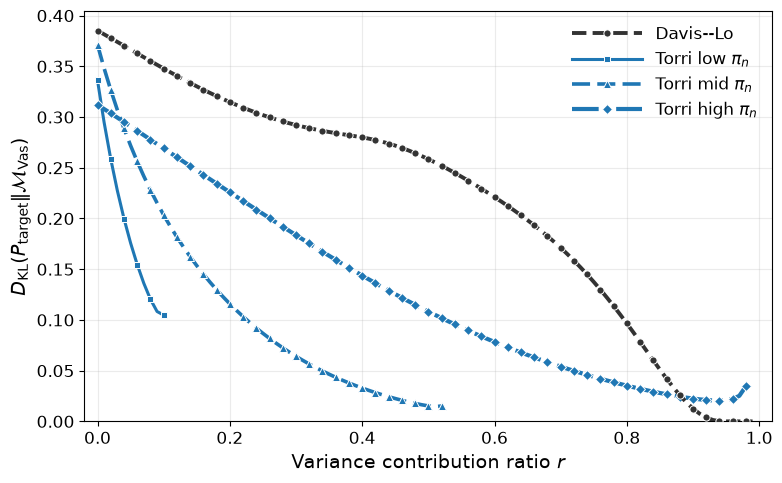

In [27]:
# ============================================================
# Figure 8: KL distance vs r
#   Hierarchical Davis-Lo
#   Hierarchical Torri[0], Torri[3], Torri[6]
#   to best-fit Vasicek
#
# Output:
#   figure4_KLprojection.pdf
#   figure4_KLprojection.png
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# Paper-ready style
# =========================
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(8.0, 5.0))

# -------------------------
# Davis--Lo
# -------------------------
df_ld_plot = df_kl.copy().sort_values("r")

ax.plot(
    df_ld_plot["r"],
    df_ld_plot["KL_LD_to_Vas"],
    color="0.20",
    linestyle="--",
    linewidth=2.8,
    marker="o",
    markersize=5.2,
    markerfacecolor="0.20",
    markeredgecolor="white",
    markeredgewidth=0.7,
    markevery=2,
    label="Davis--Lo",
    zorder=4,
)

# -------------------------
# Torri
# -------------------------
df_torri_plot = df_kl_Torri.copy()

# Handle possible column-name variation
if "KL_Torri_to_Vas" not in df_torri_plot.columns:
    if "KL_LD_to_Vas" in df_torri_plot.columns:
        df_torri_plot = df_torri_plot.rename(
            columns={"KL_LD_to_Vas": "KL_Torri_to_Vas"}
        )
    else:
        raise KeyError("Neither 'KL_Torri_to_Vas' nor 'KL_LD_to_Vas' was found.")

# In the present data:
#   Torri[0] = high pi_n
#   Torri[3] = mid pi_n
#   Torri[6] = low pi_n
#
# Use the same blue family but different markers and line styles.
torri_styles = {
    6: dict(
        color="#1f77b4",
        linestyle="-",
        linewidth=2.2,
        marker="s",
        markersize=5.0,
        markerfacecolor="#1f77b4",
        markeredgecolor="white",
        markeredgewidth=0.7,
        markevery=2,
        label=r"Torri low $\pi_n$",
        zorder=3,
    ),
    3: dict(
        color="#1f77b4",
        linestyle=(0, (5, 2)),
        linewidth=2.6,
        marker="^",
        markersize=5.4,
        markerfacecolor="#1f77b4",
        markeredgecolor="white",
        markeredgewidth=0.7,
        markevery=2,
        label=r"Torri mid $\pi_n$",
        zorder=3,
    ),
    0: dict(
        color="#1f77b4",
        linestyle="-.",
        linewidth=3.0,
        marker="D",
        markersize=5.0,
        markerfacecolor="#1f77b4",
        markeredgecolor="white",
        markeredgewidth=0.7,
        markevery=2,
        label=r"Torri high $\pi_n$",
        zorder=3,
    ),
}

# Plot in legend order: low, mid, high
for idx in [6, 3, 0]:
    g = df_torri_plot[
        df_torri_plot["Torri_index"].astype(int) == idx
    ].copy()

    if g.empty:
        continue

    g = g.sort_values("r")
    sty = torri_styles[idx]

    ax.plot(
        g["r"],
        g["KL_Torri_to_Vas"],
        **sty,
    )

# -------------------------
# Formatting
# -------------------------
ax.set_xlabel(r"Variance contribution ratio $r$")
ax.set_ylabel(
    r"$D_{\mathrm{KL}}(P_{\mathrm{target}}\|\mathcal{M}_{\mathrm{Vas}})$"
)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(bottom=0)

ax.grid(True, alpha=0.25, linewidth=0.8)

ax.legend(
    frameon=False,
    loc="upper right",
    handlelength=4.2,
    handletextpad=0.8,
)

fig.tight_layout()

# -------------------------
# Save
# -------------------------
fig.savefig(FIGURE_DIR / "fig8_environmental_kl_projection.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "fig8_environmental_kl_projection.png", dpi=300, bbox_inches="tight")

plt.show()


## Output summary

After a complete run, the main public outputs are:

### `figure/`
- `static_matched_pmf.pdf`
- `static_matched_survival.pdf`
- `fig4a_activation_probability.pdf`
- `fig4b_tailrisk_vs_activation.pdf`
- `fig4_frequency_severity_tradeoff.pdf`
- `fig8_environmental_kl_projection.pdf`

### `pdata/`
- `fig4_tail_metrics_vs_pi.csv`
- `table_vi_static_kl_projection.csv`
- `static_kl_projection_fits.csv`
- `fig8_environmental_kl_davis_lo.csv`
- `fig8_environmental_kl_torri.csv`

This notebook deliberately contains no empirical Moody's observations.
